In [1]:
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv("nba.csv")

In [3]:
data.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,NaN,5000000.0


In [4]:
data.isnull().sum()

Name         1
Team         1
Number       1
Position     1
Age          1
Height       1
Weight       1
College     85
Salary      12
dtype: int64

In [5]:
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Salary'] = data['Salary'].fillna(data['Salary'].mean())

In [6]:
data.isnull().sum()

Name         1
Team         1
Number       1
Position     1
Age          0
Height       1
Weight       1
College     85
Salary       0
dtype: int64

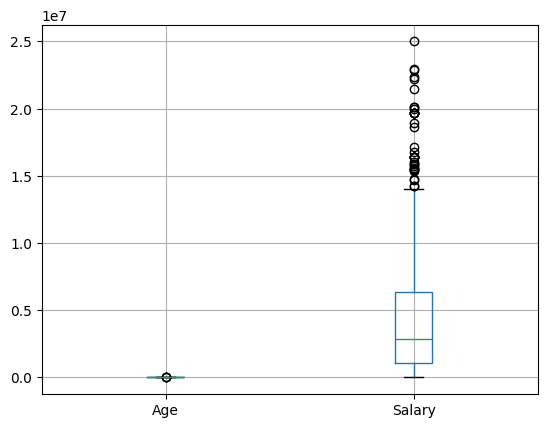

In [7]:
# sns.boxplot(x = 'Age', y = 'Salary', data=data)

import matplotlib.pyplot as plt
data.boxplot(column = ['Age', 'Salary'])
plt.show()

In [8]:
# IQR for Age
q1 = data['Age'].quantile(0.25)
q3 = data['Age'].quantile(0.75)
iqr = q3-q1

lower = q1-1.5*iqr
upper = q3+1.5*iqr

data=data[(data['Age']>=lower)&(data['Age']<= upper)]

# IQR for Salary
q1 = data['Salary'].quantile(0.25)
q3 = data['Salary'].quantile(0.75)
iqr = q3-q1

lower = q1-1.5*iqr
upper = q3+1.5*iqr

data=data[(data['Salary']>=lower)&(data['Salary']<= upper)]

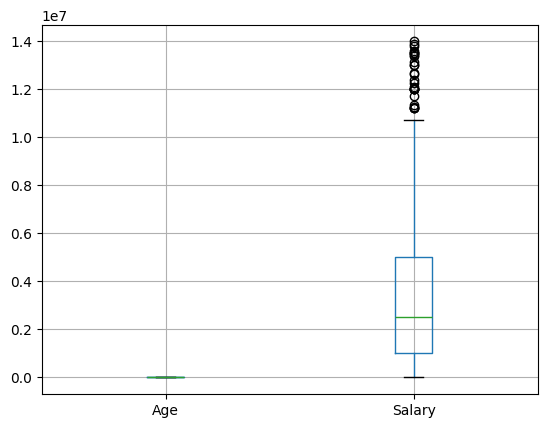

In [10]:
data.boxplot(column = ['Age', 'Salary'])
plt.show()

In [11]:
data.groupby('Age')['Salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Age,,,,,,,,
19.0,2.0,1.930440e+06,2.791658e+05,1.733040e+06,1.831740e+06,1930440.0,2.029140e+06,2127840.0
20.0,19.0,2.725791e+06,1.510913e+06,5.250930e+05,1.636920e+06,2481720.0,3.954720e+06,5703600.0
21.0,19.0,2.067380e+06,1.412350e+06,5.250930e+05,1.235480e+06,1584480.0,2.084940e+06,5758680.0
22.0,26.0,2.357963e+06,1.517378e+06,5.250930e+05,1.169190e+06,1793880.0,3.366733e+06,6331404.0
23.0,40.0,1.826012e+06,1.616056e+06,3.088800e+04,6.437732e+05,1188660.0,2.833440e+06,7070730.0
24.0,43.0,2.700032e+06,2.966840e+06,5.250930e+05,8.725295e+05,1463040.0,3.055118e+06,13500000.0
25.0,42.0,3.138954e+06,3.411175e+06,5.572200e+04,9.472760e+05,1206060.0,4.177215e+06,12700000.0
26.0,30.0,4.705870e+06,4.541582e+06,1.342150e+05,1.011162e+06,2525154.0,8.258373e+06,13913044.0
27.0,33.0,3.810763e+06,3.740827e+06,5.572200e+04,1.015421e+06,3000000.0,6.268675e+06,14000000.0


In [13]:
# Create categorical variable (Age Groups)
data['Age_Group'] = pd.cut(data['Age'], bins=5)

In [16]:
# Group by categorical variable and compute statistics
result = data.groupby('Age_Group')['Salary'].agg([
    'mean',
    'median',
    'min',
    'max',
    'std'
])

result

C:\Users\Shreyash Nathe\AppData\Local\Temp\ipykernel_18260\2188968131.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = data.groupby('Age_Group')['Salary'].agg([


,mean,median,min,max,std
Age_Group,,,,,
"(18.98, 23.0]",2.163006e+06,1.741440e+06,30888.0,7070730.0,1.537840e+06
"(23.0, 27.0]",3.478843e+06,1.969420e+06,55722.0,14000000.0,3.663073e+06
"(27.0, 31.0]",5.330138e+06,4.842684e+06,111444.0,13800000.0,3.783803e+06
"(31.0, 35.0]",4.625116e+06,4.000000e+06,200600.0,13437500.0,3.754969e+06
"(35.0, 39.0]",2.787006e+06,2.814000e+06,222888.0,8333334.0,2.106925e+06


In [19]:
# Create list of salary values for each category
salary_lists = data.groupby('Age_Group')['Salary'].apply(list)

salary_lists

C:\Users\Shreyash Nathe\AppData\Local\Temp\ipykernel_18260\943409624.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_lists = data.groupby('Age_Group')['Salary'].apply(list)


Age_Group
(18.98, 23.0]    [1148640.0, 1170960.0, 1824360.0, 3431040.0, 1...
(23.0, 27.0]     [7730337.0, 6796117.0, 4842684.105381166, 2165...
(27.0, 31.0]     [5000000.0, 12000000.0, 1500000.0, 947276.0, 8...
(31.0, 35.0]     [6300000.0, 1635476.0, 7402812.0, 947276.0, 65...
(35.0, 39.0]     [4842684.105381166, 2900000.0, 5675000.0, 3376...
Name: Salary, dtype: object